In [ ]:
!pip install -U tensorflow scikit-learn==1.4.2 scikeras matplotlib seaborn


In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
file_path = '/content/drive/MyDrive/Combined.csv'

# Read the CSV
data = pd.read_csv(file_path)

# Display first few rows
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-4143662039.py:11: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


,Unnamed: 0,Seq,Dur,RunTime,Mean,Sum,Min,Max,Proto,sTos,...,sVid,dVid,SrcTCPBase,DstTCPBase,TcpRtt,SynAck,AckDat,Label,Attack Type,Attack Tool
0,0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,icmp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
1,1,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,icmp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
2,2,3,4.998020,4.998020,4.998020,4.998020,4.998020,4.998020,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
3,3,4,4.998037,4.998037,4.998037,4.998037,4.998037,4.998037,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
4,4,5,4.999453,4.999453,4.999453,4.999453,4.999453,4.999453,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import f_classif, SelectKBest
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from scikeras.wrappers import KerasClassifier

# Handle missing values
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].median())

# Encode categorical columns
ohe_cols = ['Proto', 'State', 'Cause', 'sDSb', 'dDSb']  # adjust if needed
ohe_cols = [c for c in ohe_cols if c in data.columns]

if ohe_cols:
    data = pd.get_dummies(data, columns=ohe_cols, drop_first=True)

In [ ]:
if data['Label'].dtype == object:
    data['binary_label'] = data['Label'].apply(
        lambda x: 0 if str(x).strip().lower() in ('Benign','0') else 1
    ).astype(int)
else:
    # numeric: treat 0 as benign, non-zero as attack
    data['binary_label'] = (data['Label'] != 0).astype(int)

print("Binary label distribution (full dataset):")
print(data['binary_label'].value_counts())

#  Filter attack-only data
attack_data = data.loc[data['binary_label'] == 1].copy()


if 'Attack Type' in attack_data.columns:
    print("\nUnique values in 'Attack Type' (preview):")
    print(pd.Series(attack_data['Attack Type'].unique())[:50])

#  Categorize attack type
def categorize_attack_type(atk):
    if atk == 'Benign':
        return 'Benign'
    elif atk in ['ICMPFlood','UDPFlood','SYNFlood','HTTPFlood']:
        return 'DoS'
    elif atk in [ 'SYNScan' , 'TCPConnectScan' , 'UDPScan' ]:
        return 'Scan'
    else:
        return 'SlowrateDoS'



attack_data['Attack_Category'] = attack_data['Attack Type'].apply(categorize_attack_type)

#  Encode categories
label_encoder = LabelEncoder()
attack_data['Attack_Category'] = label_encoder.fit_transform(attack_data['Attack_Category'])

Binary label distribution (full dataset):
binary_label
1    1215890
Name: count, dtype: int64

Unique values in 'Attack Type' (preview):
0            Benign
1           SYNScan
2    TCPConnectScan
3           UDPScan
4         ICMPFlood
5          UDPFlood
6          SYNFlood
7         HTTPFlood
8       SlowrateDoS
dtype: object


In [ ]:
print(pd.Series(attack_data['Attack_Category']).value_counts())


Attack_Category
1    609028
0    477737
3     73124
2     56001
Name: count, dtype: int64


In [ ]:
# # FEATURE SELECTION USING CORRELATION MATRIX

# # Compute correlation matrix (numeric only)
# corr_matrix = attack_data.corr(numeric_only=True)
# target_corr = corr_matrix['Attack_Category']

# # Select features with correlation > 0.1
# corr_threshold = 0.1
# important_features = target_corr[abs(target_corr) > corr_threshold].index.tolist()

# # Remove target itself
# if 'Attack_Category' in important_features:
#     important_features.remove('Attack_Category')

# print("\n Features correlated with Attack_Category:")
# print(important_features)

# # Remove highly correlated (redundant) features
# corr_features = attack_data[important_features].corr(numeric_only=True)
# to_drop = set()

# for i in range(len(corr_features.columns)):
#     for j in range(i):
#         if abs(corr_features.iloc[i, j]) > 0.8:
#             to_drop.add(corr_features.columns[i])

# final_features = [f for f in important_features if f not in to_drop]

# print("\n Final selected non-redundant features:")
# print(final_features)

In [ ]:
# # Drop Non Feature Columns
# non_feature_cols = ['Unnamed: 0','Attack Tool']
# final_features = [col for col in final_features if col not in non_feature_cols]

# print(f"\n Final feature list for Level 2 model ({len(final_features)} features):")
# print(final_features)

# # Prepare Dataset
# X_cat = attack_data[final_features]
# y_cat = attack_data['Attack_Category']

In [ ]:
X_cat=attack_data.drop(['Label','binary_label','Attack_Category','Attack Type', 'Attack Tool','Unnamed: 0'],axis=1,errors='ignore')
y_cat=attack_data['Attack_Category']

# Compute ANOVA F-score
f_scores, p_values = f_classif(X_cat, y_cat)

# Create a readable table
anova_results = pd.DataFrame({
    "Feature": X_cat.columns,
    "F-Score": f_scores,
    "P-Value": p_values
})

anova_results = anova_results.sort_values(by="F-Score", ascending=False)

print("ANOVA selected features:", anova_results)

ANOVA selected features:        Feature        F-Score   P-Value
11       sHops  253970.561337  0.000000
48   Proto_tcp  220277.126943  0.000000
0          Seq  184834.205037  0.000000
49   Proto_udp  154060.631772  0.000000
19      Offset  140872.567088  0.000000
..         ...            ...       ...
39  DstTCPBase       1.010001  0.387023
64     sDSb_54       0.515034  0.671901
76    dDSb_cs4       0.515034  0.671901
36        sVid            NaN       NaN
37        dVid            NaN       NaN

[78 rows x 3 columns]


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [36 37] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
#Apply ANOVA to Select TOP 10 Features
selector = SelectKBest(score_func=f_classif, k=10)
X_anova = selector.fit_transform(X_cat, y_cat)

#Get the Names of Selected Features
selected_indices = selector.get_support(indices=True)
top_10_features = X_cat.columns[selected_indices]

print(" Top 10 Features from ANOVA:")
print(top_10_features)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [36 37] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


✅ Top 10 Features from ANOVA:
Index(['Seq', 'Min', 'Max', 'sTtl', 'sHops', 'Offset', 'AckDat', 'Proto_tcp',
       'Proto_udp', 'State_CON'],
      dtype='object')


In [ ]:
X_cat = X_cat[top_10_features]

anova_scores = pd.DataFrame({
    "Feature": X_cat.columns,
    "F_Score": selector.scores_[selected_indices],
    "p_value": selector.pvalues_[selected_indices]
})

anova_scores = anova_scores.sort_values(by="F_Score", ascending=False)
print(anova_scores.head(10))

     Feature        F_Score  p_value
4      sHops  253970.561337      0.0
7  Proto_tcp  220277.126943      0.0
0        Seq  184834.205037      0.0
8  Proto_udp  154060.631772      0.0
5     Offset  140872.567088      0.0
3       sTtl   91477.258332      0.0
9  State_CON   75815.485941      0.0
6     AckDat   64128.645183      0.0
1        Min   53377.688956      0.0
2        Max   53377.688956      0.0


In [ ]:
#  Train/Val/Test Split
X_temp_c, X_test_c, y_temp_c, y_test_c = train_test_split(
    X_cat, y_cat, test_size=0.1, stratify=y_cat, random_state=42
)
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_temp_c, y_temp_c, test_size=1/9, stratify=y_temp_c, random_state=42
)


In [ ]:
#  Balance classes
df_train = pd.concat([X_train_c, y_train_c], axis=1)
min_samples = df_train['Attack_Category'].value_counts().min()

balanced_classes = []
for label in df_train['Attack_Category'].unique():
    class_subset = df_train[df_train['Attack_Category'] == label]
    class_up = resample(class_subset, replace=True, n_samples=min_samples, random_state=42)
    balanced_classes.append(class_up)

df_train_bal = pd.concat(balanced_classes, ignore_index=True)

X_train_bal_c = df_train_bal.drop('Attack_Category', axis=1)
y_train_bal_c = df_train_bal['Attack_Category']

#  Normalize
scaler = StandardScaler()
X_train_bal_c = scaler.fit_transform(X_train_bal_c)
X_val_c = scaler.transform(X_val_c)
X_test_c = scaler.transform(X_test_c)

In [ ]:
def create_level2_model(optimizer='adam', lr=0.001, dropout_rate=0.3):
    model = Sequential()
    model.add(tf.keras.Input(shape=(X_train_bal_c.shape[1],)))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(len(np.unique(y_train_bal_c)), activation='softmax'))

    if optimizer == 'adam':
        opt = Adam(learning_rate=lr)
    else:
        opt = RMSprop(learning_rate=lr)

    model.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

In [ ]:
#  Wrap in KerasClassifier for GridSearchCV
model = KerasClassifier(
    model=create_level2_model,
    epochs=10,
    batch_size=64,
    verbose=0
)

#  Define parameter grid
param_grid = {
    "model__optimizer": ["adam", "rmsprop"],
    "model__lr": [0.001, 0.0005],
    "model__dropout_rate": [0.2, 0.3],
    "batch_size": [64, 128],
    "epochs": [10]
}

#  KFold setup
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#  Grid Search
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=kfold,
    n_jobs=-1,  verbose=2)
grid_result = grid.fit(X_train_bal_c, y_train_bal_c, validation_data=(X_val_c, y_val_c))


Fitting 5 folds for each of 16 candidates, totalling 80 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



 Best Parameters (Level 2) 
{'batch_size': 64, 'epochs': 10, 'model__dropout_rate': 0.2, 'model__lr': 0.001, 'model__optimizer': 'adam'}
Best CV Accuracy: 0.9847
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step

[LEVEL 2] Attack Category Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      0.99      0.99     47774
         DoS       0.99      0.96      0.98     60903
        Scan       0.91      1.00      0.95      5600
 SlowrateDoS       0.79      0.99      0.88      7312

    accuracy                           0.98    121589
   macro avg       0.92      0.99      0.95    121589
weighted avg       0.98      0.98      0.98    121589



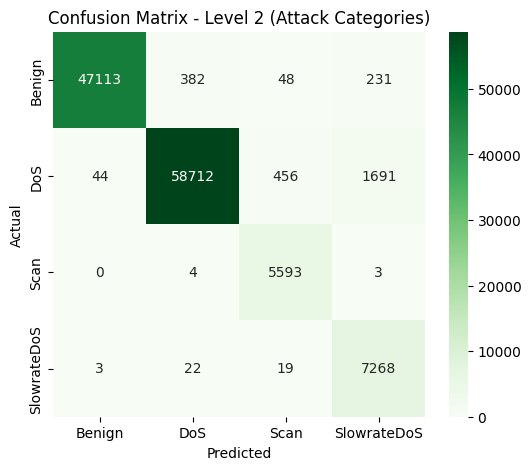

In [ ]:
print("\n Best Parameters (Level 2) ")
print(grid_result.best_params_)
print(f"Best CV Accuracy: {grid_result.best_score_:.4f}")

#  Evaluate best model on test set
best_model = grid_result.best_estimator_.model_
y_pred_c = np.argmax(best_model.predict(X_test_c), axis=1)

print("\n[LEVEL 2] Attack Category Classification Report:")
print(classification_report(y_test_c, y_pred_c, target_names=label_encoder.classes_))

#  Confusion Matrix
cm2 = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Level 2 (Attack Categories)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()